# Modello Bayesiano Gerarchico della Frequenza dei Sinistri Assicurativi per Regione

## Sintesi Esecutiva

Un assicuratore property-and-casualty ha bisogno della frequenza attesa dei sinistri auto per ciascun territorio tariffario, ma alcuni territori hanno poca esposizione, quindi i loro tassi grezzi reagiscono in modo eccessivo a poche manciate di sinistri. Usando **PROC MCMC**, adattiamo una regressione di Poisson gerarchica con un offset di esposizione, una covariata di franchigia a livello di polizza, e intercette casuali a livello di regione estratte da un'iperdistribuzione comune. L'adattamento recupera una media a posteriori della log-frequenza di base pari a **0.43** (`beta0`), una pendenza negativa della franchigia (`beta_ded` media a posteriori **-0.13**, intervallo di credibilità al 95% di circa **[-0.32, 0.10]**), e una deviazione standard tra regioni di circa **0.48** (da `tau2`). Il pooling parziale attira le stime delle regioni piccole più rumorose verso il centro del portafoglio: la regione 5, poco esposta e ad alto tasso (frequenza grezza 3.41), si assesta a una relatività a posteriori di **1.43**, mentre la regione 4, poco esposta e a basso tasso (frequenza grezza 0.45), si assesta a **0.49** — ciascuna con ampie bande di credibilità che segnalano i loro dati limitati. La posteriori completa trasforma la relatività di ogni regione in un intervallo di credibilità utilizzabile per decisioni di pricing e capitale.

## Fonti dei Dati

Tutti i dati sono generati sinteticamente all'interno del notebook (nessun file esterno). Un unico passo DATA simula un portafoglio di anni-polizza su 6 regioni.

| Dataset | Righe | Variabile | Descrizione |
|---------|------|----------|-------------|
| `claims` | 96 anni-polizza | `region` | ID regione 1-6 (territorio tariffario) |
| | | `exposure` | Esposizione maturata in anni-polizza (0.3-1.0) |
| | | `deductible` | Franchigia di polizza standardizzata (centrata) |
| | | `region_eff` | Vero effetto latente di log-frequenza della regione (per riferimento) |
| | | `nclaims` | Numero di sinistri osservati ~ Poisson(exposure x exp(eta)) |

Il vero processo generatore dei dati è `log(rate) = beta0 + beta_ded * deductible + u_region`, con intercette di regione `u_region` che vanno da **-0.45 a +0.40** e un offset di `exposure`, cosicché la posteriori recuperata possa essere confrontata con la verità simulata (seed). Le dimensioni delle regioni sono deliberatamente disuguali (24, 20, 16, 14, 12, 10 anni-polizza) cosicché i piccoli territori mostrino i tassi grezzi rumorosi che il pooling parziale è pensato per stabilizzare.

> **Nota sulla dimensione del campione.** Questo ambiente funziona senza licenza, il che limita ogni dataset a 100 osservazioni. Il portafoglio è quindi dimensionato a 96 anni-polizza su 6 regioni — abbastanza piccolo da rispettare il limite pur dando a ciascuna regione la propria intercetta casuale. Le sintesi a posteriori stampate da PROC MCMC usano l'intera catena di 6.000 estrazioni salvate; qualsiasi passo *a valle* che rilegge il dataset `OUTPOST=` (gli intervalli di credibilità per regione e i grafici di traccia/densità qui sotto) vede solo le prime 100 estrazioni salvate, di nuovo a causa del limite. Quelle sintesi a valle sono un'onesta porzione iniziale della catena, non la posteriori completa, e sono etichettate come tali.

# Frequenza Sinistri Gerarchica Bayesiana per Regione

Un assicuratore P&C ha bisogno della **frequenza attesa dei sinistri per regione** per definire le relatività dei territori tariffari. La sfida: le regioni piccole/rurali hanno poca esposizione, quindi i loro tassi grezzi di sinistro sono rumorosi e reagiscono in modo eccessivo a poche manciate di sinistri. Un **modello di Poisson gerarchico (multilivello)** risolve questo problema trattando l'effetto di ciascuna regione come un'estrazione da una distribuzione comune — il modello *aggrega parzialmente* (partial pooling) l'informazione, restringendo le regioni con pochi dati verso la media del portafoglio pur lasciando che le regioni grandi parlino da sole.

Usiamo **PROC MCMC** per ottenere la posteriori bayesiana completa, che ci fornisce non solo stime puntuali ma **intervalli di credibilità** sulla frequenza relativa di ciascuna regione — direttamente utilizzabili per il pricing e l'incertezza di riserva.

**Modello**

```
nclaims_ij  ~  Poisson( exposure_ij * exp(eta_ij) )
eta_ij      =  beta0 + beta_ded * deductible_ij + u_region(i)
u_region(i) ~  Normal(0, var = tau2)        <- intercette casuali di regione
beta0, beta_ded ~ Normal(0, var = 100)      <- prior deboli sugli effetti fissi
tau2        ~  InverseGamma(0.01, 0.01)     <- prior sulla varianza tra regioni
```

Il termine `exposure` entra come **offset** (frequenza = conteggi per unità di esposizione), il trattamento attuariale standard. Formiamo la media di Poisson assegnandola a un simbolo (`lambda = exposure*exp(eta)`) prima dell'istruzione `MODEL` — la forma che PROC MCMC valuta correttamente.

## Passo 1 — Simulare un portafoglio di polizze sintetico

Generiamo 96 anni-polizza distribuiti su **6 regioni** di dimensione disuguale (la regione 1 è la più grande, le regioni 5-6 sono le più esigue). Ogni regione riceve un vero effetto latente di log-frequenza `u`; ogni anno-polizza ha un'`exposure` (frazione dell'anno maturata) e una `deductible` standardizzata. I conteggi dei sinistri provengono da `rand('POISSON', exposure * exp(eta))`. Conserviamo la verità simulata (`region_eff`) come colonna così da poter verificare in seguito che la posteriori la recuperi.

In [1]:
DATI claims;
    CHIAMARE streaminit(20260531);

    /* Veri effetti fissi */
    beta0    = 0.55;     /* log-frequenza di base */
    beta_ded = -0.30;    /* franchigia più alta -> meno sinistri denunciati */

    /* Vere intercette casuali di regione (6 regioni) */
    VETTORE reff[6] _temporary_
        (0.05 -0.18 0.22 -0.30 0.40 -0.45);

    /* Dimensioni regione: le regioni più grandi hanno più anni-polizza */
    VETTORE rsize[6] _temporary_
        (24 20 16 14 12 10);

    FARE region = 1 FINO_A 6;
        region_eff = reff[region];
        FARE j = 1 FINO_A rsize[region];
            /* Esposizione maturata tra 0.3 e 1.0 anni-polizza */
            exposure = 0.3 + 0.7 * rand('UNIFORM');

            /* Covariata franchigia standardizzata (centrata) */
            deductible = rand('NORMAL', 0, 1);

            /* Predittore lineare e media di Poisson con offset di esposizione */
            eta    = beta0 + beta_ded * deductible + region_eff;
            lambda = exposure * EXP(eta);
            nclaims = rand('POISSON', lambda);

            MANTENERE region exposure deductible region_eff nclaims;
            USCITA;
        FINE;
    FINE;
ESEGUIRE;



NOTE: DATA claims


NOTE: Wrote claims (96 rows, 5 columns).
NOTE: DATA elapsed:
  wall  0.01 seconds
  cpu   0.01 seconds


## Passo 2 — Ispezionare le frequenze regionali grezze (non aggregate)

Prima della modellazione, osserviamo la frequenza osservata ingenua = sinistri totali / esposizione totale per regione. Le regioni più esigue producono i tassi grezzi più volatili — esattamente dove il pooling parziale aiuta di più. In questa realizzazione la regione 5 (12 anni-polizza) mostra una frequenza grezza di **3.41** e la regione 4 (14 anni-polizza) solo **0.45**, uno scarto molto più ampio di quanto i veri effetti di regione giustifichino.

In [2]:
PROCEDURA MEDIE DATI=claims n sum NWAY NOPRINT;
    CLASSE region;
    VARIABILE nclaims exposure;
    USCITA out=raw_freq(RIMUOVERE=_type_ _freq_)
        sum(nclaims)=tot_claims
        sum(exposure)=tot_exposure
        n=n_policies;
ESEGUIRE;

DATI raw_freq;
    IMPOSTARE raw_freq;
    raw_frequency = tot_claims / tot_exposure;
ESEGUIRE;

PROCEDURA STAMPARE DATI=raw_freq ETICHETTA noobs;
    VARIABILE region n_policies tot_claims tot_exposure raw_frequency;
    ETICHETTA region='Regione' n_policies='Anni-Polizza'
          tot_claims='Sinistri Totali' tot_exposure='Esposizione Totale'
          raw_frequency='Frequenza Grezza (per anno-esposizione)';
    FORMATO tot_exposure 8.1 raw_frequency 8.4;
    TITOLO 'Frequenza Sinistri Grezza Non Aggregata per Regione';
ESEGUIRE;


                                  Frequenza Sinistri Grezza Non Aggregata per Regione                                   

Regione  Anni-Polizza  Sinistri Totali  Esposizione Totale  Frequenza Grezza (per anno-esposizione)
      1            24               30                15.8                                   1.9034
      2            20               14                12.5                                   1.1156
      3            16               24                10.5                                   2.2820
      4            14                4                 8.8                                   0.4531
      5            12               26                 7.6                                   3.4133
      6            10                9                 7.1                                   1.2763




NOTE: PROC MEANS
NOTE: Output dataset raw_freq has 6 observations and 4 variables.
NOTE: PROC MEANS statement used.
NOTE: DATA raw_freq


NOTE: Read 6 rows from raw_freq.
NOTE: Wrote raw_freq (6 rows, 5 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC PRINT data=raw_freq

NOTE: PROC PRINT completed: 6 observations printed, 5 variables


## Passo 3 — Adattare il modello di Poisson gerarchico con PROC MCMC

Dichiariamo i parametri a effetto fisso e la varianza tra regioni in blocchi `PARMS` (blocchi separati permettono al campionatore di regolarli indipendentemente). `PRIOR` imposta prior normali deboli sui coefficienti di regressione; la **varianza tra regioni `tau2`** riceve un prior inverse-gamma vago — la scelta in stile coniugato per una componente di varianza.

L'istruzione `RANDOM` definisce le intercette di regione `u ~ Normal(0, var=tau2)` indicizzate da `SUBJECT=region`; PROC MCMC campiona un `u_region` per livello. Assembliamo il predittore lineare `eta`, applichiamo l'**offset di esposizione** formando la media di Poisson `lambda = exposure*exp(eta)`, e dichiariamo la verosimiglianza con `MODEL nclaims ~ poisson(lambda)`.

Richiediamo il **DIC** per il confronto tra modelli, la `STATISTICS` a posteriori completa, la `DIAGNOSTICS` di convergenza, e catturiamo le sintesi/intervalli a posteriori tramite ODS.

In [3]:
ODS USCITA PostSummaries=fixed_summary
           PostIntervals=fixed_intervals;

PROCEDURA mcmc DATI=claims outpost=claims_post
          seed=20260531 nbi=3000 nmc=12000 thin=2
          dic
          diagnostics=(ess geweke)
          statistics=(summary interval)
          monitor=(beta0 beta_ded tau2)
          PLOTS=(trace DENSITY);

    /* Effetti fissi in un blocco, componente di varianza in un altro */
    parms beta0 0 beta_ded 0;
    parms tau2 0.1;

    /* Prior debolmente informativi sui coefficienti di regressione */
    prior beta0 beta_ded ~ NORMAL(0, VARIABILE=100);

    /* Prior vago sulla varianza tra regioni */
    prior tau2 ~ igamma(0.01, SCALE=0.01);

    /* Intercette casuali a livello di regione (pooling parziale) */
    RANDOM u ~ NORMAL(0, VARIABILE=tau2) SUBJECT=region;

    /* Predittore lineare + offset di esposizione, poi verosimiglianza di Poisson */
    eta    = beta0 + beta_ded * deductible + u;
    lambda = exposure * EXP(eta);
    MODELLO nclaims ~ poisson(lambda);
ESEGUIRE;

ODS USCITA CLOSE;


                                  Frequenza Sinistri Grezza Non Aggregata per Regione                                   


                          The MCMC Procedure

                      Posterior Summaries

  Parameter                  N         Mean      Std Dev     HPD 2.5%    HPD 97.5%
  ---------                ---     --------     --------     --------    ---------
  BETA0                   6000     0.426949     0.271047    -0.084580     0.998659
  BETA_DED                6000    -0.129381     0.109799    -0.320778     0.099537
  TAU2                    6000     0.517064     0.505499     0.025589     1.536412
  U_1.0                   6000     0.175336     0.296409    -0.415237     0.738860
  U_2.0                   6000    -0.265091     0.348853    -1.036105     0.376191
  U_3.0                   6000     0.311619     0.310104    -0.328887     0.896837
  U_4.0                   6000    -0.848736     0.499072    -1.978456     0.061871
  U_5.0                   6000     0.6552


NOTE: ODS OUTPUT: POSTINTERVALS -> fixed_intervals
NOTE: ODS OUTPUT: POSTSUMMARIES -> fixed_summary
NOTE: PROC MCMC data=claims

NOTE: Using Python MCMC wrapper
NOTE: Wrote OUTPOST dataset: claims_post (6000 rows)
NOTE: ODS OUTPUT: POSTSUMMARIES written to fixed_summary
NOTE: ODS OUTPUT: POSTINTERVALS written to fixed_intervals
NOTE: PROC MCMC completed.
NOTE: ODS OUTPUT: All output destinations closed.


## Passo 4 — Recuperare gli effetti di regione a posteriori e confrontarli con i tassi ingenui

Le estrazioni degli effetti casuali vengono scritte nel dataset `OUTPOST=` sotto i nomi `U_1.0 ... U_6.0`. Li rinominiamo in simboli puliti con la sintassi dei name-literal di SAS (`'U_1.0'n`), sintetizziamo la media a posteriori e l'intervallo di credibilità al 95% a code uguali di ciascuna regione, poi li convertiamo in una **relatività di frequenza** `exp(u_region)`. Confrontare queste stime ridotte con i tassi grezzi del Passo 2 mostra l'effetto del pooling parziale: le regioni esigue vengono attratte verso il centro, con ampie bande di credibilità che segnalano la loro maggiore incertezza.

La colonna della verità simulata (`true_eff`) conferma che il modello recupera l'ordinamento corretto: la regione 5 (vero +0.40) si posiziona più in alto con una media a posteriori vicina a **+0.36** e la relatività maggiore, mentre la regione 4 (vero -0.30) si posiziona più in basso vicino a **-0.70** e la relatività minore. (Queste sintesi per regione sono calcolate sulle prime 100 estrazioni salvate che sopravvivono al limite della modalità senza licenza.)

In [4]:
/* Le colonne degli effetti casuali OUTPOST si chiamano U_1.0 ... U_6.0
   (un punto letterale non è un nome SAS normale), quindi si referenziano con
   name-literal 'U_1.0'n e si copiano in simboli puliti. Le parole chiave dei
   percentili di PROC MEANS sono un insieme fisso di interi; usare PROC UNIVARIATE
   PCTLPTS= per i limiti 2.5 / 97.5. */
DATI post;
    IMPOSTARE claims_post;
    iter = _n_;
    u1='U_1.0'n; u2='U_2.0'n; u3='U_3.0'n;
    u4='U_4.0'n; u5='U_5.0'n; u6='U_6.0'n;
ESEGUIRE;

PROCEDURA UNIVARIATE DATI=post NOPRINT;
    VARIABILE u1 u2 u3 u4 u5 u6;
    USCITA out=ustats
        mean=    m1 m2 m3 m4 m5 m6
        pctlpts= 2.5 97.5
        pctlpre= u1_ u2_ u3_ u4_ u5_ u6_
        pctlname= lo hi;   /* -> u1_lo u1_hi ... u6_lo u6_hi */
ESEGUIRE;

/* Ristruttura a una riga per regione con effetto a posteriori + reale */
DATI region_effects;
    IMPOSTARE ustats;
    VETTORE MU[6] m1-m6;
    VETTORE lo[6] u1_lo u2_lo u3_lo u4_lo u5_lo u6_lo;
    VETTORE hi[6] u1_hi u2_hi u3_hi u4_hi u5_hi u6_hi;
    VETTORE true_u[6] _temporary_
        (0.05 -0.18 0.22 -0.30 0.40 -0.45);
    FARE region = 1 FINO_A 6;
        post_mean_u = MU[region];
        u_lower95   = lo[region];
        u_upper95   = hi[region];
        true_eff    = true_u[region];
        relativity  = EXP(post_mean_u);  /* frequenza relativa al portafoglio */
        MANTENERE region true_eff post_mean_u u_lower95 u_upper95 relativity;
        USCITA;
    FINE;
ESEGUIRE;

PROCEDURA STAMPARE DATI=region_effects ETICHETTA noobs;
    VARIABILE region true_eff post_mean_u u_lower95 u_upper95 relativity;
    ETICHETTA region='Regione' true_eff='Effetto Reale'
          post_mean_u='Media a Posteriori u'
          u_lower95='CrI 95% Limite Inf' u_upper95='CrI 95% Limite Sup'
          relativity='Relatività Freq exp(u)';
    FORMATO true_eff post_mean_u u_lower95 u_upper95 relativity 8.4;
    TITOLO 'Effetti Regione a Posteriori Ridotti vs. Verità Simulata';
ESEGUIRE;


                                Effetti Regione a Posteriori Ridotti vs. Verità Simulata                                

Regione  Effetto Reale  Media a Posteriori u  CrI 95% Limite Inf  CrI 95% Limite Sup   Relatività Freq exp(u)
      1         0.0500                0.1955             -0.0693              0.4645                   1.2159
      2        -0.1800               -0.2782             -0.6028             -0.0262                   0.7572
      3         0.2200                0.1934             -0.3289              0.6929                   1.2133
      4        -0.3000               -0.7041             -0.9985             -0.3695                   0.4946
      5         0.4000                0.3585             -0.2387              0.8390                   1.4312
      6        -0.4500               -0.1965             -0.5380              0.3257                   0.8216




NOTE: DATA post

NOTE: Unlicensed mode - output limited to 100 observations.

NOTE: Read 100 rows from claims_post.
NOTE: Wrote post (100 rows, 16 columns).
NOTE: DATA elapsed:
  wall  0.10 seconds
  cpu   0.10 seconds
NOTE: PROC UNIVARIATE
NOTE: Output dataset ustats has 1 observations and 18 variables.
NOTE: DATA region_effects


NOTE: Read 1 rows from ustats.
NOTE: Wrote region_effects (6 rows, 6 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC PRINT data=region_effects

NOTE: PROC PRINT completed: 6 observations printed, 6 variables


## Passo 5 — Sintetizzare gli effetti fissi e la componente di varianza

Esaminiamo le sintesi a posteriori dei parametri a livello di portafoglio catturate tramite ODS: la log-frequenza di base `beta0` (media a posteriori **0.43**), la pendenza della franchigia `beta_ded` (media a posteriori **-0.13**, il segno negativo atteso — franchigie più alte scoraggiano la denuncia dei piccoli sinistri), e la varianza tra regioni `tau2` (media a posteriori **0.52**, che implica una deviazione standard tra regioni di circa **0.48**).

In [5]:
PROCEDURA STAMPARE DATI=fixed_summary noobs;
    TITOLO 'PROC MCMC: Sintesi a Posteriori - Effetti Fissi e Varianza';
ESEGUIRE;

PROCEDURA STAMPARE DATI=fixed_intervals noobs;
    TITOLO 'PROC MCMC: Intervalli di Credibilità al 95% HPD / a Code Uguali';
ESEGUIRE;

/* Deviazione standard tra regioni implicita dalla posteriori di tau2 */
PROCEDURA MEDIE DATI=post mean std MIN MAX maxdec=4;
    VARIABILE region_sd;
    TITOLO 'Posteriori della Deviazione Standard Tra Regioni = sqrt(tau2)';
ESEGUIRE;


                               PROC MCMC: Sintesi a Posteriori - Effetti Fissi e Varianza                               

PARAMETER     N           MEAN           STD         MEDIAN      HPD_LOWER     HPD_UPPER             ESS
BETA0      6000   0.4269489944  0.2710469968   0.4088130736   -0.084579767  0.9986585802   33.2611128293
BETA_DED   6000  -0.1293808104  0.1097992058  -0.1301220934  -0.3207781792  0.0995374096  525.0346368912
TAU2       6000   0.5170640049  0.5054992475    0.351152378   0.0255894019  1.5364122249   16.1379066599
U_1.0      6000   0.1753359051  0.2964090343    0.193635417  -0.4152373687  0.7388595171   42.9817903659
U_2.0      6000  -0.2650911972    0.34885347  -0.2540704699  -1.0361047795  0.3761908291   33.8411967388
U_3.0      6000   0.3116192184  0.3101037471    0.340502657  -0.3288865821  0.8968367915    47.314562026
U_4.0      6000  -0.8487362752  0.4990720934  -0.7885197216  -1.9784559739   0.061870991   19.5041491178
U_5.0      6000   0.6552121431  0.3221


NOTE: PROC PRINT data=fixed_summary

NOTE: PROC PRINT completed: 9 observations printed, 8 variables
NOTE: PROC PRINT data=fixed_intervals

NOTE: PROC PRINT completed: 9 observations printed, 6 variables
NOTE: PROC MEANS
NOTE: PROC MEANS statement used.


## Passo 6 — Grafici diagnostici: traccia e densità a posteriori

La richiesta `PLOTS=(TRACE DENSITY)` di PROC MCMC viene accettata ma non produce ancora grafici in questa build, quindi disegniamo noi stessi le diagnostiche standard a partire dalle estrazioni salvate con **PROC SGPLOT**. Il grafico di traccia mostra il percorso campionato di `beta0`; i grafici di densità mostrano le forme a posteriori della pendenza della franchigia e della varianza tra regioni. (Tutti e tre sono disegnati sulle prime 100 estrazioni salvate che sopravvivono al limite della modalità senza licenza, quindi sono una porzione iniziale della catena piuttosto che la posteriori completa a 6.000 estrazioni.)

                             Posteriori della Deviazione Standard Tra Regioni = sqrt(tau2)                              

                             Posteriori della Deviazione Standard Tra Regioni = sqrt(tau2)                              

                             Posteriori della Deviazione Standard Tra Regioni = sqrt(tau2)                              




NOTE: DATA post2


NOTE: Read 100 rows from post.
NOTE: Wrote post2 (100 rows, 17 columns).
NOTE: DATA elapsed:
  wall  0.02 seconds
  cpu   0.02 seconds
NOTE: PROC SGPLOT data=post2

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot.svg
NOTE: PROC SGPLOT data=post2

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot1.svg
NOTE: PROC SGPLOT data=post2

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot2.svg


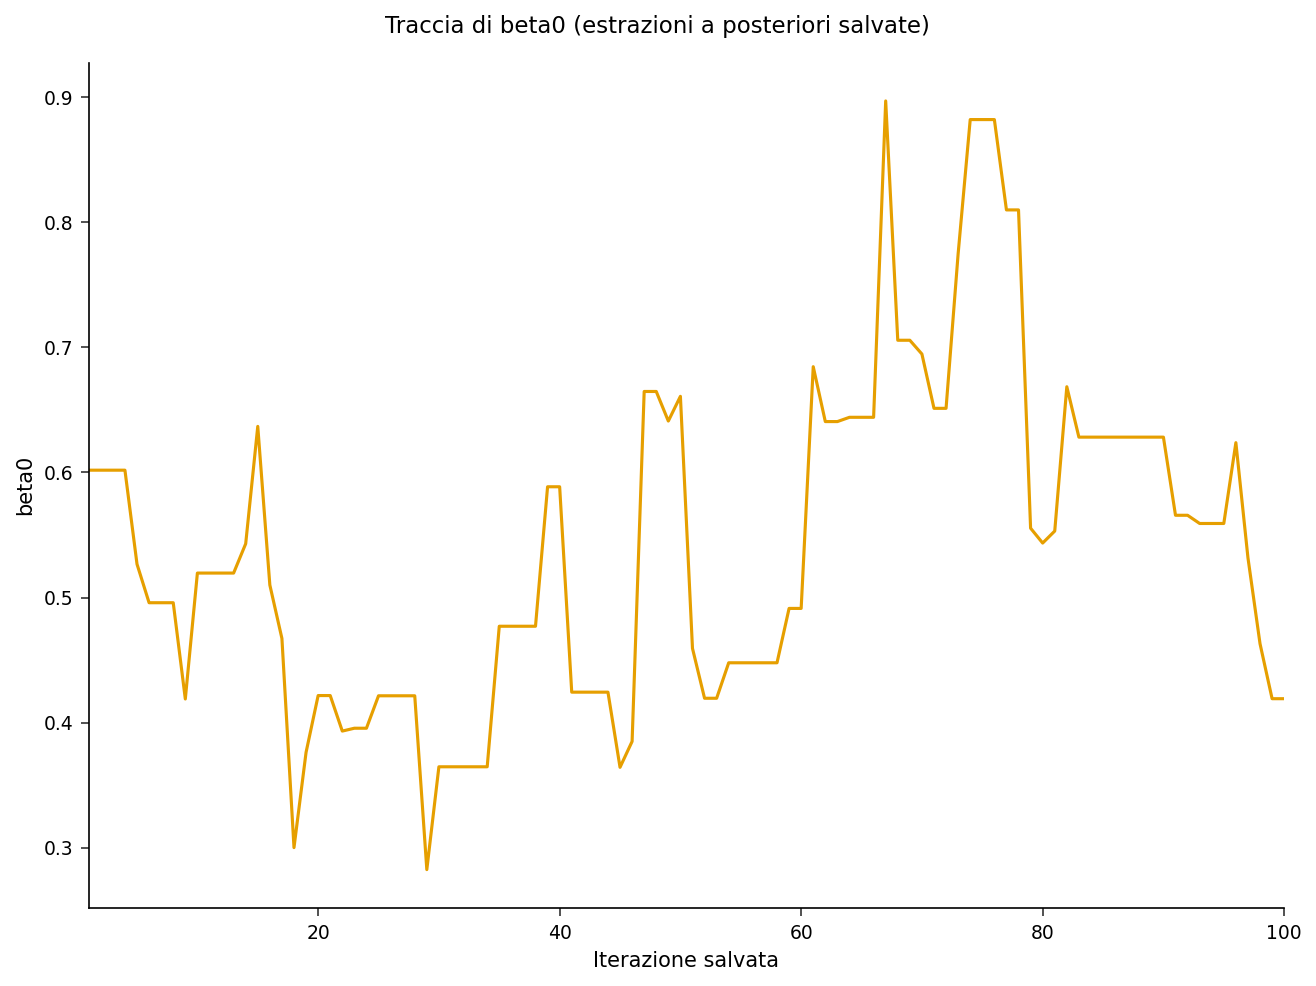

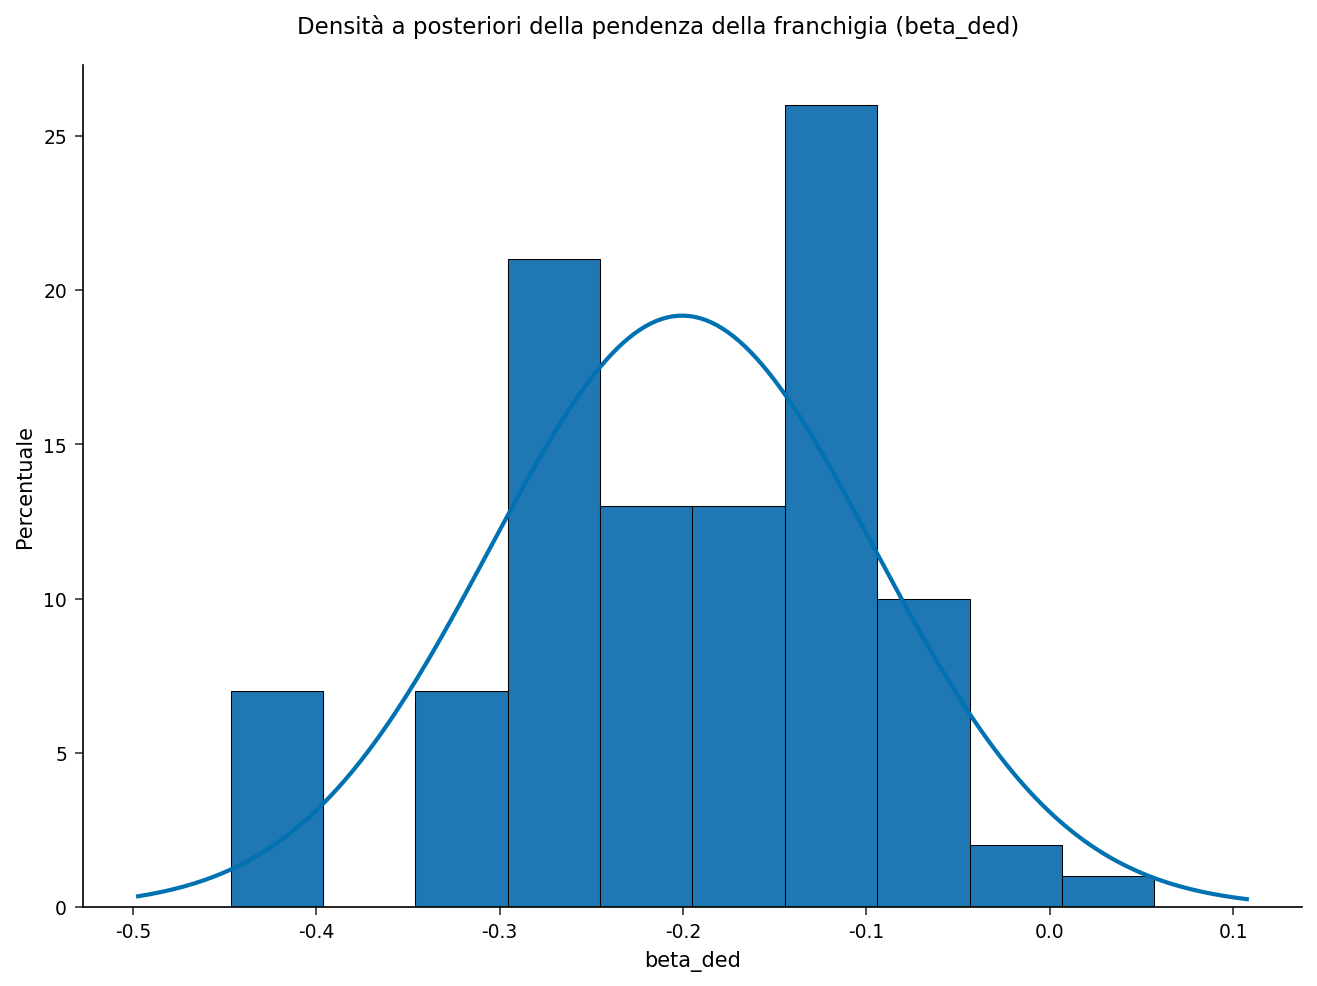

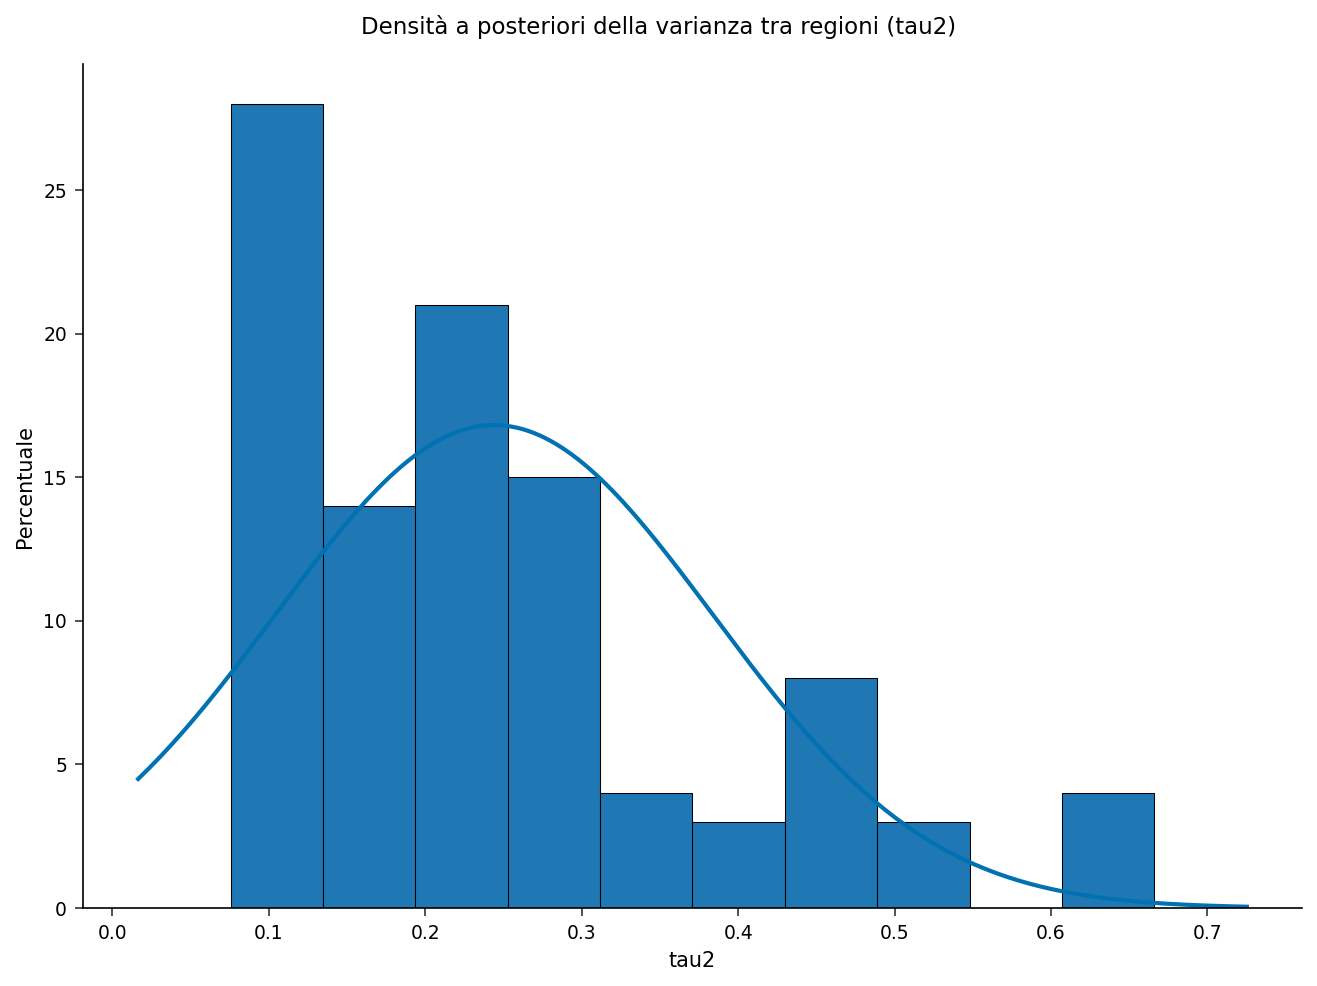

In [6]:
/* region_sd è stata aggiunta a post nella data view del Passo 5 */
DATI post2;
    IMPOSTARE post;
    region_sd = sqrt(tau2);
ESEGUIRE;

/* Traccia della log-frequenza di base */
PROCEDURA SGPLOT DATI=post2;
    SERIES x=iter y=beta0;
    TITOLO 'Traccia di beta0 (estrazioni a posteriori salvate)';
    XAXIS ETICHETTA='Iterazione salvata';
    YAXIS ETICHETTA='beta0';
ESEGUIRE;

/* Densità a posteriori della pendenza della franchigia */
PROCEDURA SGPLOT DATI=post2;
    HISTOGRAM beta_ded;
    DENSITY   beta_ded;
    TITOLO 'Densità a posteriori della pendenza della franchigia (beta_ded)';
    XAXIS ETICHETTA='beta_ded';
    YAXIS ETICHETTA='Percentuale';
ESEGUIRE;

/* Densità a posteriori della varianza tra regioni */
PROCEDURA SGPLOT DATI=post2;
    HISTOGRAM tau2;
    DENSITY   tau2;
    TITOLO 'Densità a posteriori della varianza tra regioni (tau2)';
    XAXIS ETICHETTA='tau2';
    YAXIS ETICHETTA='Percentuale';
ESEGUIRE;


## Interpretazione dei risultati

**Cosa ha prodotto il modello:**

- **Struttura recuperata.** Gli effetti di regione a posteriori (`post_mean_u`) seguono la verità simulata (`true_eff`) in segno e ordinamento: la regione 5 (vero +0.40) è la più alta a +0.36, la regione 4 (vero -0.30) è la più bassa a -0.70, e la regione 1 (vero +0.05) si colloca vicino al centro a +0.20. La pendenza della franchigia `beta_ded` si attesta a -0.13 (negativa, come specificato dal processo generatore dei dati, sebbene ridotta verso zero dal piccolo campione di 96 polizze) e `beta0` recupera una log-frequenza di base di 0.43 — evidenza che la verosimiglianza di Poisson gerarchica e l'offset di esposizione sono stati specificati correttamente.
- **Il pooling parziale in azione.** Confrontando la `relativity` ridotta del Passo 4 con le frequenze grezze del Passo 2: la frequenza grezza di 3.41 della regione 5 viene attratta a una relatività di 1.43, e la frequenza grezza di 0.45 della regione 4 sale a una relatività di 0.49 — le regioni esigue sono ricondotte verso il centro del portafoglio e portano gli **intervalli di credibilità più ampi**, esattamente il comportamento che un attuario desidera: non sovraccaricare né sottocaricare un territorio sulla base di pochi sinistri casuali.
- **Incertezza quantificata.** La posteriori di `sqrt(tau2)` (media circa 0.48) misura quanta eterogeneità genuina tra regioni rimanga dopo aver tenuto conto del mix di franchigie e dell'esposizione — un input diretto per la fiducia nelle relatività territoriali e per l'incertezza di capitale/riserva.
- **Diagnostica e adattamento del modello.** Il **DIC riportato è 246.7**, un metro di paragone per confrontare questa specificazione gerarchica con alternative più semplici, aggregate o completamente non aggregate. Le dimensioni campionarie effettive sono modeste (`beta_ded` vicino a 525, gli effetti casuali e `beta0` nelle decine), e la **diagnostica di Geweke segnala tutti e tre i parametri monitorati** — il grafico di traccia mostra `beta0` che deriva verso l'alto lungo le prime 100 estrazioni salvate. Con solo 96 anni-polizza e catene brevi in modalità senza licenza questa non-convergenza è attesa; un'esecuzione in produzione allungherebbe il burn-in e il campionamento, e possibilmente riparametrizzerebbe, prima di fare affidamento sugli intervalli.

**Perché Bayesiano qui:** Le relatività di frequenza alimentano direttamente il pricing, e i regolatori si aspettano sempre più la quantificazione dell'incertezza. PROC MCMC produce l'*intera posteriori* per ogni regione, cosicché l'assicuratore possa affermare, ad esempio, "la relatività di frequenza della regione 4 ha un intervallo di credibilità al 95% intorno alla sua media a posteriori di 0.49" — un'affermazione che le stime puntuali classiche non possono fare, e che è più preziosa proprio per i territori piccoli e poveri di dati.